In [2]:
# Data manipulation
import pandas as pd
import numpy as np


# Data visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import cm

# warning management library
import warnings

# Text Mining
import nltk
nltk.download('punkt')
from wordcloud import WordCloud
from collections import Counter
nltk.download('stopwords')
from nltk.stem import WordNetLemmatizer
nltk.download('wordnet')
nltk.download('punkt_tab')

# Machine learning
import sklearn
from sklearn.feature_extraction.text import TfidfVectorizer

# Similarity metrics
from sklearn.metrics.pairwise import cosine_similarity as cossim

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\smazo\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\smazo\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\smazo\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\smazo\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [3]:
warnings.filterwarnings('ignore')
sns.set()
pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)

### 1. Loading of file title.basics.tz and selecting relevant columns

In [5]:
titles = pd.read_csv("../Transformed_Data/movies_info.csv")
#https://developer.imdb.com/non-commercial-datasets/

In [6]:
titles.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14807 entries, 0 to 14806
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   tconst         14807 non-null  object
 1   primaryTitle   14807 non-null  object
 2   genres         14807 non-null  object
 3   imdb_id        14807 non-null  object
 4   plot_synopsis  14807 non-null  object
 5   tags           14807 non-null  object
dtypes: object(6)
memory usage: 694.2+ KB


In [8]:
titles = titles[["primaryTitle", "genres", "plot_synopsis", "tags"]]
titles.head()

,primaryTitle,genres,plot_synopsis,tags
0,The House of the Devil,Horror Short,The film opens with a large bat flying into a ...,paranormal gothic
1,Beauty and the Beast,Family Fantasy Romance,A widower merchant lives in a mansion with his...,fantasy
2,Cinderella,Drama Family Fantasy,"A prologue in front of the curtain, suppressed...",fantasy
3,A Trip to the Moon,Adventure Comedy Fantasy,"At a meeting of the Astronomic Club, its presi...",psychedelic satire
4,The Land Beyond the Sunset,Drama Fantasy Short,Joe is an impoverished New York newsboy who li...,fantasy storytelling


In [15]:
titles.rename(columns={"primaryTitle": "title", "plot_synopsis": "synopsis"}, inplace=True)
titles.head()


,title,genres,synopsis,tags
0,The House of the Devil,Horror Short,The film opens with a large bat flying into a ...,paranormal gothic
1,Beauty and the Beast,Family Fantasy Romance,A widower merchant lives in a mansion with his...,fantasy
2,Cinderella,Drama Family Fantasy,"A prologue in front of the curtain, suppressed...",fantasy
3,A Trip to the Moon,Adventure Comedy Fantasy,"At a meeting of the Astronomic Club, its presi...",psychedelic satire
4,The Land Beyond the Sunset,Drama Fantasy Short,Joe is an impoverished New York newsboy who li...,fantasy storytelling


### 2. Starting Natural Language Processing

#### 2.1 Lemmatization and Tokenization functions

In [10]:
# list of french stopwords : https://www.ranks.nl/stopwords/french
french_stopwords = ["alors","au","aucun","aussi","autre","avant","avec","avoir","bon","car","ce","cela","ces","ceux","chaque","ci",
                    "comme","comment","dans","des","du",
"dedans","dehors","depuis","devrait","doit","donc","début", "de","elle","elles","en","encore","essai","est","et","eu","fait","faites",
"fois","font","hors","ici","il","ils","je","juste",
"la","le","les","leur","là","ma","maintenant","mais","mes","mien","moins","mon","mot","même","ni","notre","nous","ou","où","par",
"parce","pas","peut","peu","plupart","pour","pourquoi",
"quand","que","quel","quelle","quelles","quels","qui","sa","sans","ses","seulement","si","sien","son","sont","sous","soyez","sur",
"ta","tandis","tellement","tels","tes","ton","tous",
"tout","trop","très","tu","voient","vont","votre","vous","vu","ça","étaient","état","étions","été","être", "un"]

In [11]:
# creating a list of stopwords for a specific text : with text most common words, and with french end english typical stopwords list
def stopwords_list(text,sw_nb):
    # Lemmatization
    text=text.lower()
    lemmatizer = WordNetLemmatizer()
    text=lemmatizer.lemmatize(text)
    
    # Tokenization
    words_list=nltk.word_tokenize(text)
    words_list= [word for word in words_list if word.isalnum()]
    
    # Suppress digits
    words_list=[w for w in words_list if w.isalpha()]
    
    # wordcount and stopwords
    word_counts = Counter(words_list)
    stopwords_list=[count[0] for count in word_counts.most_common(sw_nb)]
    
    sw = set()
    sw.update(stopwords_list)
    sw.update(tuple(nltk.corpus.stopwords.words('english')))
    sw=list(sw)
    # adding french stopwords
    for fsw in french_stopwords:
        sw.append(fsw)
    return sw

In [12]:
# Text lemmatization and tokenization
def tokenize_text(text):
    # Lemmatization
    text=text.lower()
    lemmatizer = WordNetLemmatizer()
    text=lemmatizer.lemmatize(text)
    
    # Tokenization
    words_list=nltk.word_tokenize(text)
    words_list= [word for word in words_list if word.isalnum()]
    
    # Suppress digits
    words_list=[lemmatizer.lemmatize(w) for w in words_list if w.isalpha()]
    return words_list

In [13]:
# definition of a wordcloud function to have a small visualisation
def word_cloud(words_list):
    wordcloud=WordCloud()
    sentence=' '.join(words_list)
    wordcloud.generate(sentence)
    # create a figure
    fig, ax = plt.subplots(1,1, figsize = (9,6))
    # add interpolation = bilinear to smooth things out
    plt.imshow(wordcloud, interpolation='bilinear')
    # and remove the axis
    plt.axis("off")

#### 2.2 Text pre-processing

In [ ]:
text = (titles[["title"]] + " "+titles.loc[:,"synopsis"]+" ").sum()

In [14]:
text

"Carmencita Le clown et ses chiens Poor Pierrot Un bon bock Blacksmith Scene Chinese Opium Den Corbett and Courtney Before the Kinetograph Edison Kinetoscopic Record of a Sneeze Miss Jerry Leaving the Factory Akrobatisches Potpourri The Arrival of a Train The Photographical Congress Arrives in Lyon The Waterer Watered Around a Cabin Boat Leaving the Port Italienischer Bauerntanz Das boxende Känguruh The Clown Barber The Derby 1895 Blacksmith Scene The Sea Opening of the Kiel Canal The Oxford and Cambridge University Boat Race The Messers. Lumière at Cards Cordeliers' Square in Lyon Fishing for Goldfish Baby's Meal Rough Sea at Dover Jumping the Blanket Die Serpentintänzerin Horse Trick Riders Arrivée d'un train gare de Vincennes Watering the Flowers Awakening of Rip Sea Bathing The Ball Game Barnet Horse Fair Barque sortant du port de Trouville Bataille de neige Bateau-mouche sur la Seine Batteuse à vapeur Le bivouac Les blanchisseuses Bois de Boulogne Boulevard des Italiens The Boxing

In [15]:
sw=stopwords_list(text,10)

In [16]:
sw[:20]

['theirs',
 'through',
 "we'd",
 'then',
 'because',
 'ours',
 "wouldn't",
 'we',
 'wouldn',
 'few',
 "they'll",
 'those',
 'all',
 'from',
 'm',
 "it'd",
 'a',
 'where',
 'at',
 'both']

In [17]:
text = (titles_reduced.iloc[:,1] + " " + titles_reduced.iloc[:,2] + " ").sum()
words_list = tokenize_text(text)

In [18]:
words_list_wo_sw=[w for w in words_list if w not in sw]

In [19]:
words_list_wo_sw[:20]

['carmencita',
 'documentary',
 'short',
 'clown',
 'chiens',
 'animation',
 'short',
 'poor',
 'pierrot',
 'animation',
 'comedy',
 'romance',
 'bock',
 'animation',
 'short',
 'blacksmith',
 'scene',
 'short',
 'chinese',
 'opium']

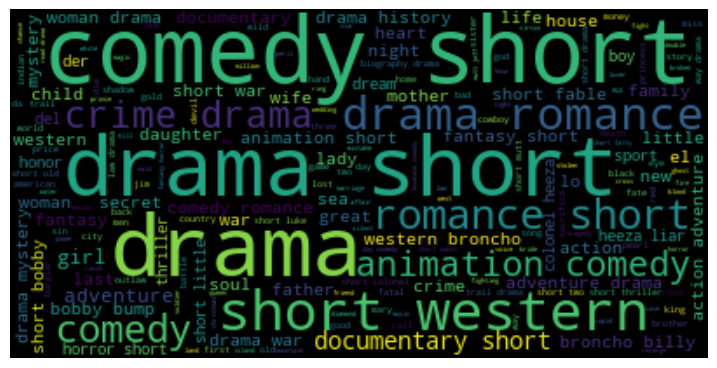

In [20]:
word_cloud(words_list_wo_sw)

#### 2.3 TF-IDF

In [21]:
tfidf = TfidfVectorizer(tokenizer=tokenize_text,stop_words=sw)

In [22]:
words_tfidf = tfidf.fit_transform((titles_reduced.iloc[:,1] + " " + titles_reduced.iloc[:,2] + " "))

In [23]:
words_tfidf.shape

(10000, 7581)

### 3. Recommandations using cosine similarity

#### 3.1 recommendation function

In [24]:
cossim_matrix = cossim(words_tfidf,words_tfidf)

In [25]:
cossim_matrix.shape

(10000, 10000)

<Axes: >

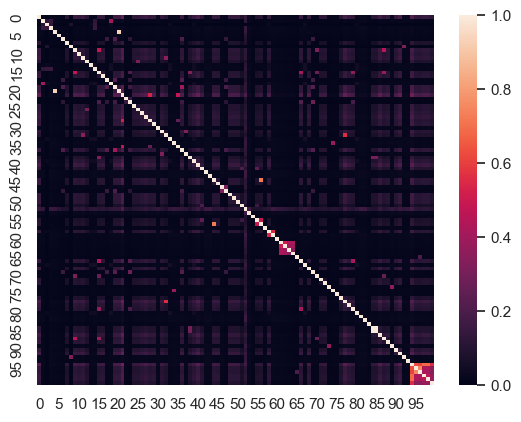

In [26]:
sns.heatmap(cossim_matrix[:100, :100])

In [27]:
# generate serie with the index of each movie
indices = pd.Series(titles_reduced.index, index=titles_reduced['title'].apply(lambda x: x.lower())) #.drop_duplicates()

In [28]:
indices[:10]

title
carmencita                                     0
le clown et ses chiens                         1
poor pierrot                                   2
un bon bock                                    3
blacksmith scene                               4
chinese opium den                              5
corbett and courtney before the kinetograph    6
edison kinetoscopic record of a sneeze         7
miss jerry                                     8
leaving the factory                            9
dtype: int64

In [29]:
def get_reco(title, cosine_sim=cossim_matrix):
    # Get the index of the movie that matches the title
    title = title.lower()
    idx = indices[title]

    # Get the pairwsie similarity scores of all movies with that movie
    sim_scores = list(enumerate(cosine_sim[idx]))

    # Sort the movies based on the similarity scores
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)

    # Get the scores of the 10 most similar movies
    sim_scores = sim_scores[1:11]

    # Get the movie indices
    movie_indices = [i[0] for i in sim_scores]

    # Return the top 10 most similar movies
    return titles_reduced[['title', "genres"]].iloc[movie_indices]

#### 3.2 Examples of recommandation

In [30]:
# recommandation for the first movie
print("first movie title: "+titles_reduced['title'].iloc[0])
get_reco(titles_reduced['title'].iloc[0])

first movie title: Carmencita


,title,genres
21,The Sea,Documentary Short
94,Place Saint-Augustin,Documentary Short
9863,China,Documentary Short
9625,St. Croix,Documentary Short
40,Bateau-mouche sur la Seine,Documentary Short
77,La gare Saint-Lazare,Documentary Short
9773,Before Breakfast,Documentary Short
9518,The Storm,Documentary
4718,The War of the World,Documentary
91,Melbourne,Documentary Short


In [31]:
titles_reduced[['title', "genres"]].iloc[:20]

,title,genres
0,Carmencita,Documentary Short
1,Le clown et ses chiens,Animation Short
2,Poor Pierrot,Animation Comedy Romance
3,Un bon bock,Animation Short
4,Blacksmith Scene,Short
5,Chinese Opium Den,Short
6,Corbett and Courtney Before the Kinetograph,Short Sport
7,Edison Kinetoscopic Record of a Sneeze,Documentary Short
8,Miss Jerry,Romance
9,Leaving the Factory,Documentary Short


In [32]:
movie_index = 2
print("Movie title: "+titles_reduced['title'].iloc[movie_index])
get_reco(titles_reduced['title'].iloc[movie_index])

Movie title: Poor Pierrot


,title,genres
7730,A Daughter of the Poor,Comedy Drama
9411,"Rich Man, Poor Man",Drama Romance
489,"Pierrot, Murderer",Short
9366,The Poor Rich Man,Comedy Drama Western
5838,Poor Schmaltz,Comedy
4234,A Madonna of the Poor,Drama Short
268,Arrivée de Pierette et Pierrot,Short
2005,Poor Jenny,Short
8684,A.W.O.L.,Animation Comedy Short
7106,Poor Little Peppina,Drama
